In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("uber_processed.csv")
df.head()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,trip_distance_km,bearing,pickup_dist_from_center,dropoff_dist_from_center,hour,day_of_week,month,year,is_weekend,is_rush_hour
0,7.5,-73.999817,40.738354,-73.999512,40.723217,1,1.683323,179.124609,2.888822,1.280903,19,3,5,2015,0,1
1,7.7,-73.994355,40.728225,-73.994710,40.750325,1,2.457590,359.302804,1.976096,4.279659,20,4,7,2009,0,0
2,12.9,-74.005043,40.740770,-73.962565,40.772647,1,5.036377,45.254124,3.111167,7.594400,21,0,8,2009,0,0
3,5.3,-73.976124,40.790844,-73.965316,40.803349,3,1.661683,33.192997,9.035634,10.635729,8,4,6,2009,0,1
4,16.0,-73.925023,40.744085,-73.973082,40.761247,5,4.475450,295.254931,7.659096,6.059087,17,3,8,2014,0,1


-When testing reggressor models, we should get back the og features we removed like, longitudes and latidue and so on.

-we also dont need to normalize the features.

-what we need is to still have the is_Xday or so features

In [7]:
day_mapping = {
    0: 'monday', 
    1: 'tuesday', 
    2: 'wednesday', 
    3: 'thursday', 
    4: 'friday', 
    5: 'saturday', 
    6: 'sunday'
}
df['day_name'] = df['day_of_week'].map(day_mapping)
df = pd.get_dummies ( df, columns =  ['day_name'], prefix = 'is', dtype = int  )
df = df.drop ( columns = ['day_of_week'] )





In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

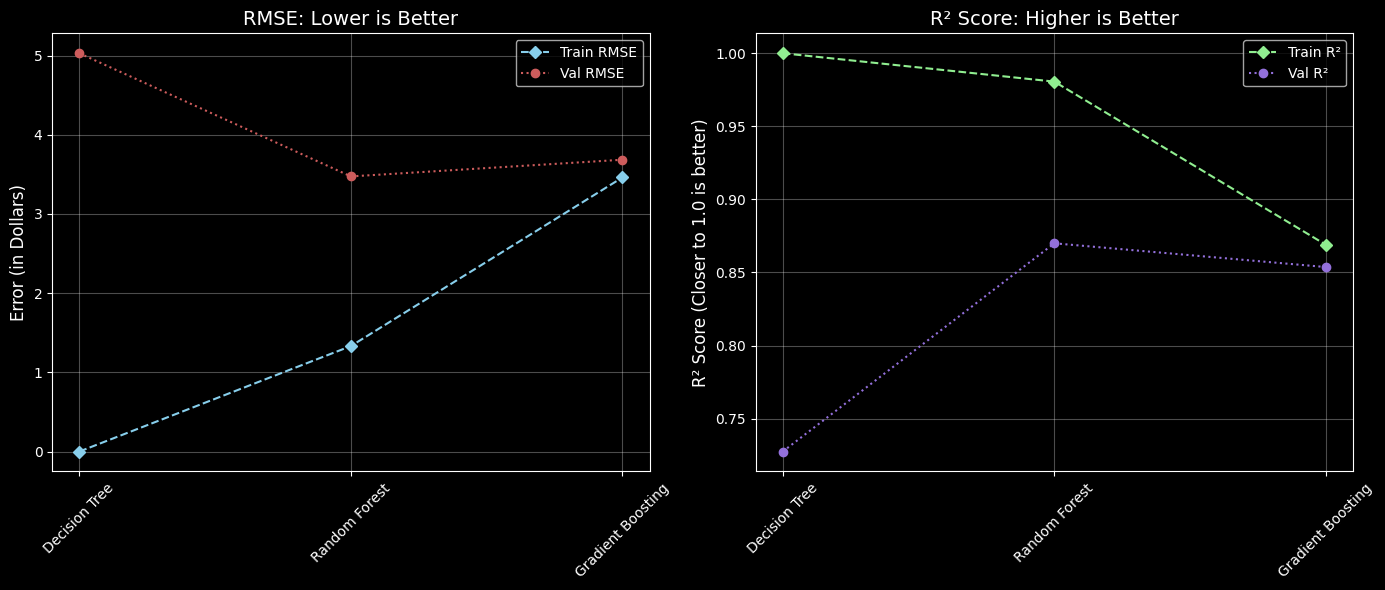


--- Final Validation Scores ---
Decision Tree: RMSE = 5.03 | R² = 0.7275
Random Forest: RMSE = 3.47 | R² = 0.8700
Gradient Boosting: RMSE = 3.68 | R² = 0.8537


In [9]:
x = df.drop( columns = 'fare_amount' )
y = df['fare_amount']

X_temp, X_test, y_temp, y_test = train_test_split(x, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=(0.15/0.85), random_state=42)

# no need to scale bruh

models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

train_rmse_list = [] 
val_rmse_list = [] 
train_r2_list = []
val_r2_list   = []

model_names = list(models.keys()) 

for name, model in models.items():

    
    model.fit(X_train, y_train)

  
    
    train_preds = model.predict(X_train)
    val_preds = model.predict(X_val)
    
 
    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    val_rmse = np.sqrt(mean_squared_error(y_val, val_preds))
    
    train_r2 = r2_score(y_train, train_preds)
    val_r2 = r2_score(y_val, val_preds)
    
    train_rmse_list.append(train_rmse)
    val_rmse_list.append(val_rmse)
    train_r2_list.append(train_r2)
    val_r2_list.append(val_r2)
plt.style.use('dark_background')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot(model_names, train_rmse_list, label='Train RMSE', marker='D', color='skyblue', linestyle='--')
ax1.plot(model_names, val_rmse_list, label='Val RMSE', marker='o', color='indianred', linestyle=':')
ax1.set_title('RMSE: Lower is Better', fontsize=14)
ax1.set_ylabel('Error (in Dollars)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(model_names, train_r2_list, label='Train R²', marker='D', color='lightgreen', linestyle='--')
ax2.plot(model_names, val_r2_list, label='Val R²', marker='o', color='mediumpurple', linestyle=':')
ax2.set_title('R² Score: Higher is Better', fontsize=14)
ax2.set_ylabel('R² Score (Closer to 1.0 is better)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print("\n--- Final Validation Scores ---")
for i in range(len(model_names)):
    print(f"{model_names[i]}: RMSE = {val_rmse_list[i]:.2f} | R² = {val_r2_list[i]:.4f}")




- Decision Tree completly overfitted the data, splitting until it has a rule for each row in the data which is apparent in its training rmse 0 and R2  thats 1, but all those values go out of the window when tested on vald set.

-Random Forest is the best: by buidling 100 different decision trees and averaging their answers it smoothed out the overfitting problem although as we can see i the gap between train and valid, theres a tiny bit of overfitting

-Gradient Boost learnt well but Random Forest still outperforms



From this we can see that Random Forset performs the best among all of the regressor model, time to test it against Test data.

In [10]:
best_model = models["Random Forest"]

test_preds = best_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
test_r2 = r2_score(y_test, test_preds)

print(f"Final Test Performance — Random Forest")
print(f"Test RMSE = {test_rmse:.2f} | Test R² = {test_r2:.4f}")

Final Test Performance — Random Forest
Test RMSE = 3.37 | Test R² = 0.8705


Random Forest is by far the best model, why we will use to predict prices.

In [11]:
import joblib

# saving the model to disk
best_model = models["Random Forest"]


joblib.dump(best_model, 'uber_rf_model.pkl')

print("Model saved successfully!")

Model saved successfully!
